In [1]:
from nl_vlm import PropGeom, PropMesh, Vehicle, VLM, WindField
from nl_vlm.dynamics.rotor import rotate_vehicle_mesh
from nl_vlm.preprocess import generate_polars
from nl_vlm.reporting import SimReporter

import numpy as np

# ------------------------------- parameters -------------------------------
rho = 1.225                 # density [kg/m^3]
rpm = 1250                  # rotational speed [rpm]
R_tip = 1.143               # tip radius [m]
R_hub = 0.286
num_blades = 2
J = 0.00                    # advance ratio; 0 = hover

# --- atmosphere (feeds the polar Re/Mach) ---
mu = 1.81e-5                # dynamic viscosity [Pa*s]
a_sound = 343.0             # speed of sound [m/s]

# --- XFOIL alpha sweep (polar generation) ---
alpha_i = -30.0              # start alpha [deg]
alpha_f = 30.0              # end alpha [deg]
alpha_step = 0.25           # alpha increment [deg]

com_position = np.array([0, 0, 0])
initial_body_velocity = np.array([0, 0, 0])
initial_euler_attitude = np.array([0, 0, 0])   # (roll, pitch, yaw) [rad]

# --------------------------------- paths ----------------------------------
BLADE_DIR   = '../data/blades/cardona_tung'
AIRFOIL_DIR = '../data/airfoils/cardona_tung/airfoil'
POLAR_DIR   = '../data/polars/cardona_tung'
XFOIL_EXE   = '../tools/xfoil/xfoil.exe' 

airfoil_dist_file = f'{BLADE_DIR}/cardona_tung_airfoildist.csv'
chorddist_file    = f'{BLADE_DIR}/cardona_tung_chorddist.csv'
pitchdist_file    = f'{BLADE_DIR}/cardona_tung_pitchdist.csv'
sweepdist_file    = f'{BLADE_DIR}/cardona_tung_sweepdist.csv'
# this blade has no heightdist

# ----------------------------- polar couplings -----------------------------
nonlinear_lift = True
profile_drag = True

# --------------------------- polar generation ------------------------------
REGENERATE_POLARS = False

if REGENERATE_POLARS:
    generate_polars(
        airfoil_dist_file=airfoil_dist_file,
        chorddist_file=chorddist_file,
        airfoil_dir=AIRFOIL_DIR,
        out_dir=POLAR_DIR,
        xfoil_exe=XFOIL_EXE,
        R_tip=R_tip, rpm=rpm, J=J,
        rho=rho, mu=mu, a_sound=a_sound,
        alpha_i=alpha_i, alpha_f=alpha_f, alpha_step=alpha_step,
    )

# ------------------------------- geometry / mesh -------------------------------
geometry = PropGeom(
    airfoil_distribution_file=airfoil_dist_file,
    chorddist_file=chorddist_file,
    pitchdist_file=pitchdist_file,
    sweepdist_file=sweepdist_file,
    airfoil_path=AIRFOIL_DIR,
    polar_path=POLAR_DIR,
    R_tip=R_tip, R_hub=R_hub, num_blades=num_blades,
)
propeller_mesh = PropMesh(geometry, span_resolution=21, chord_resolution=5)
vehicle = Vehicle(propeller_mesh, hub_positions=None, spin_directions=[1])
vehicle_mesh = vehicle.generate_vehicle()

omega_rad = rpm * 2 * np.pi / 60
omega_dict = {'Propeller_1': np.array([0, 0, omega_rad])}
magVinf = J * rpm / 60 * (2 * R_tip)
freestream = np.array([0, 0, -magVinf])

# ------------------------- time-stepping over azimuth -------------------------
n_rev      = 1                       # number of revolutions
n_step_rev = 5                       # steps per ONE revolution
total_steps = n_rev * n_step_rev     # total time steps
d_psi = 2 * np.pi / n_step_rev       # azimuth turned each step [rad]
dt = d_psi / omega_rad               # physical time per azimuth step [s]

sim = SimReporter(total_steps)
sim.announce(vehicle_mesh, omega_dict, rho, freestream,
             span_res=propeller_mesh.span_resolution, chord_res=propeller_mesh.chord_resolution)

forces, moments = [], []
solved_mesh = None
for step in range(total_steps):
    psi = step * d_psi
    mesh = rotate_vehicle_mesh(vehicle_mesh, {'Propeller_1': psi})            # rotate blade
    solver = VLM(mesh, propeller_mesh, verbose=False,                         # solve VLM (quiet)
                 nonlinear_lift=nonlinear_lift, profile_drag=profile_drag)
    
    fm = solver.calculate_total_forces_and_moments(
        propeller_mesh=mesh, dt=dt, rho=rho, time_step=step + 1,
        body_velocity=initial_body_velocity, freestream=freestream,
        omega=omega_dict, wind_field=None, com_position=com_position,
        euler_angles=initial_euler_attitude,
    )
    forces.append(fm['Propeller_1']['force'])
    moments.append(fm['Propeller_1']['moment'])
    if step == 0:
        solved_mesh = mesh
    sim.step(step + 1)

sim.summary(np.mean(forces, axis=0), np.mean(moments, axis=0))

vehicle_mesh = solved_mesh

  NL-VLM  |  analysis starting
  Rotors        : 1
  Blades/rotor  : 2
  Resolution    : 21 span x 5 chord  (160 panels)
  Rotor speed   : 1250 rpm  (130.9 rad/s)
  Air density   : 1.2250 kg/m^3
  Freestream    : [ 0.  0. -0.] m/s
--------------------------------------------------------
  solving Propeller_1  [########################] 100.0%   time step 5/5
--------------------------------------------------------
  VLM solved  (mean over 5 time steps)
    Propeller_1:  mean thrust Fz = +401.6906 N    mean torque Mz = -4.1173e+01 N*m


C:\Users\USER\AppData\Local\Temp\ipykernel_12632\705916245.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


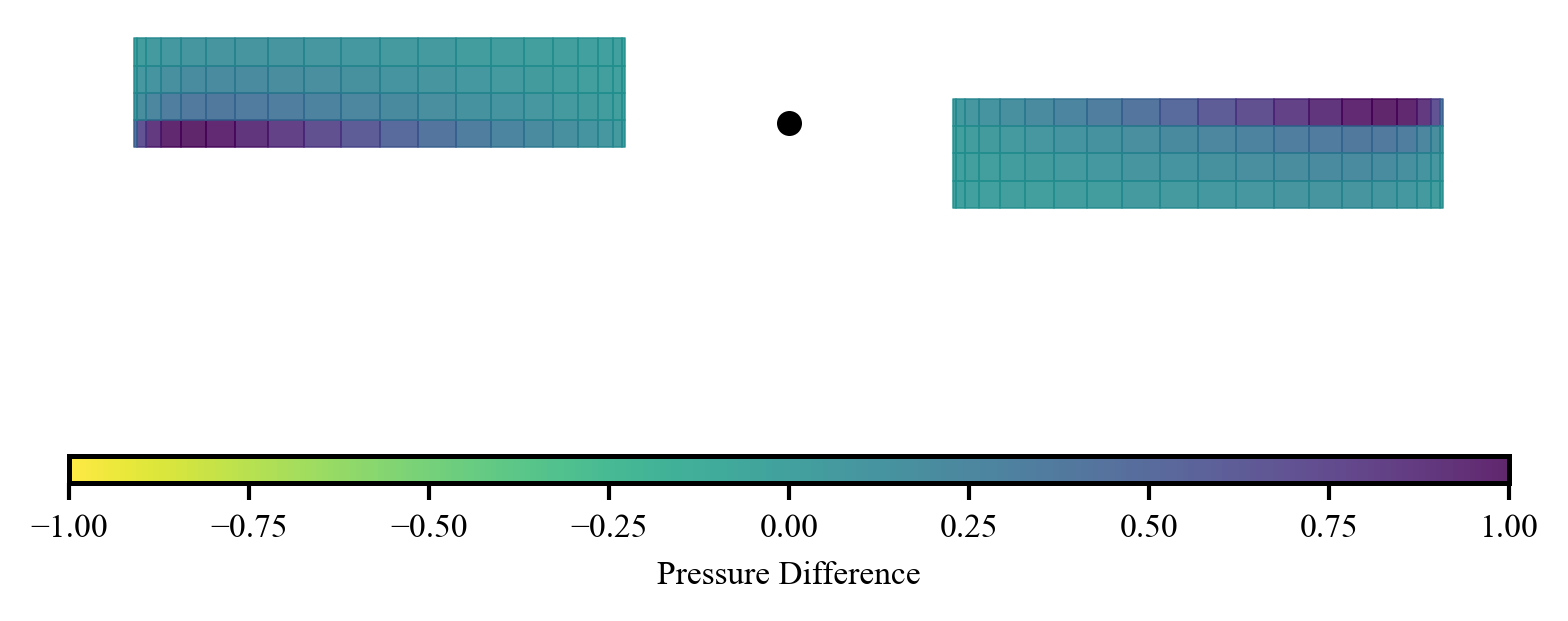

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# --- Journal font settings ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.2
})

propeller_key = 'Propeller_1'
propeller_data = vehicle_mesh[propeller_key]

fig = plt.figure(figsize=(6, 3), dpi=300)
ax = fig.add_axes([0.1, 0.2, 0.8, 0.7])  # unchanged

hub_position = np.array(propeller_data['Hub Position'])
blade_keys = list(propeller_data['Blades'].keys())

all_pressures = [p for blade_key in blade_keys 
                 for p in propeller_data['Blades'][blade_key]['Pressure Difference'].values()]
max_abs_pressure = max(abs(min(all_pressures)), abs(max(all_pressures)))

patches = []
pressure_values = []

for blade_key in blade_keys:
    blade_data = propeller_data['Blades'][blade_key]
    for panel_index, panel in blade_data['Panels'].items():
        patches.append(Polygon([(-p[1], p[0]) for p in panel], closed=True))
        pressure = blade_data['Pressure Difference'][panel_index]
        pressure = max(pressure, 0)
        pressure_values.append(pressure / max_abs_pressure if max_abs_pressure != 0 else 0)

collection = PatchCollection(
    patches,
    cmap='viridis_r',
    alpha=0.85,
    edgecolors='face',
    linewidths=0.4,
    antialiased=True
)

collection.set_array(np.array(pressure_values))

vmin = -max(abs(min(pressure_values)), abs(max(pressure_values)))
collection.set_clim(vmin, -vmin)

ax.add_collection(collection)

# --- Colorbar position---
cax = fig.add_axes([0.1, 0.15, 0.8, 0.03])
cbar = plt.colorbar(collection, cax=cax, orientation='horizontal')
cbar.set_label('Pressure Difference')
cbar.ax.tick_params(length=4, width=1)
cbar.set_label('Pressure Difference', fontsize=8)
cbar.ax.tick_params(labelsize=8) 

all_points = np.array([(-p[1], p[0]) for blade_key in blade_keys
                       for panel in propeller_data['Blades'][blade_key]['Panels'].values()
                       for p in panel])

x_min, y_min = np.min(all_points, axis=0)
x_max, y_max = np.max(all_points, axis=0)
margin = 0.05

ax.set_xlim(x_min - margin*(x_max-x_min), x_max + margin*(x_max-x_min))
ax.set_ylim(y_min - margin*(y_max-y_min), y_max + margin*(y_max-y_min))
ax.set_aspect('equal')

ax.plot(-hub_position[1], hub_position[0], 'ko', markersize=5)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# Vector export
# plt.savefig("Propeller_pressure_distribution.pdf", bbox_inches='tight')

plt.show()